# Modélisation du temps final — Marathon de Paris 2026

L'objectif est de prédire le temps d'arrivée officiel (`officialTime`) à partir des caractéristiques des athlètes et des données des premiers splits intermédiaires.

**Plan**
1. Data Engineering
2. Entraînement — Ridge et ElasticNet
3. Évaluation sur le jeu de test
4. Intervalles de confiance des coefficients (Bootstrap)
5. Visualisations

## 0. Imports et configuration

In [1]:
import sys
sys.path.insert(0, '.') 

import numpy as np
import polars as pl

from config import (
    CONFIDENCE_LEVEL,
    N_BOOTSTRAP,
    N_SPLITS,
    NATIONALITY_MIN_COUNT,
)
from data_engineering import build_dataset, split_features_target
from train import evaluate_model, prepare_arrays, train_elasticnet, train_ridge
from bootstrap import bootstrap_confidence_intervals, significant_features
from visualization import (
    plot_confidence_intervals,
    plot_metrics_comparison,
    plot_predicted_vs_actual,
    plot_residuals,
)

print(f"Paramètres actifs :")
print(f"  Splits utilisés     : {N_SPLITS}")
print(f"  Seuil nationalités  : {NATIONALITY_MIN_COUNT}")
print(f"  Itérations bootstrap: {N_BOOTSTRAP}")
print(f"  Niveau de confiance : {CONFIDENCE_LEVEL:.0%}")

Paramètres actifs :
  Splits utilisés     : 3
  Seuil nationalités  : 100
  Itérations bootstrap: 500
  Niveau de confiance : 95%


## 1. Data Engineering

Le pipeline effectue les opérations suivantes dans l'ordre :
- **Suppression des DNF** : tout athlète avec un split manquant est retiré
- **Suppression des fuites** : rankings globaux, pace/speed globaux (calculés a posteriori)
- **Regroupement des nationalités rares** : les nationalités représentées par moins de `NATIONALITY_MIN_COUNT` athlètes sont regroupées dans la catégorie `OTHER`
- **One-Hot Encoding** : `sex`, `category`, `nationality`

In [2]:
df = build_dataset(n_splits=N_SPLITS, nationality_min_count=NATIONALITY_MIN_COUNT)

print(f"Dimensions du dataset final : {df.shape}")
print(f"Valeurs manquantes          : {df.null_count().sum_horizontal().sum()}")
print(f"\nAperçu des colonnes :")
print(df.columns)

Dimensions du dataset final : (57220, 61)
Valeurs manquantes          : 0

Aperçu des colonnes :
['sex_F', 'sex_M', 'category_CF - U18F', 'category_EAH - U10H', 'category_EF - U23F', 'category_EH - U23H', 'category_JF - U20F', 'category_JH - U20H', 'category_M0F', 'category_M0H', 'category_M10H', 'category_M1F', 'category_M1H', 'category_M2F', 'category_M2H', 'category_M3F', 'category_M3H', 'category_M4F', 'category_M4H', 'category_M5F', 'category_M5H', 'category_M6F', 'category_M6H', 'category_M7F', 'category_M7H', 'category_M8F', 'category_M8H', 'category_M9F', 'category_M9H', 'category_MH - U16H', 'category_SF', 'category_SH', 'nationality_AU', 'nationality_BE', 'nationality_BR', 'nationality_CA', 'nationality_CH', 'nationality_CN', 'nationality_CO', 'nationality_DE', 'nationality_DK', 'nationality_ES', 'nationality_FR', 'nationality_GB', 'nationality_IE', 'nationality_IT', 'nationality_JP', 'nationality_MA', 'nationality_MX', 'nationality_NL', 'nationality_NO', 'nationality_OTHER',

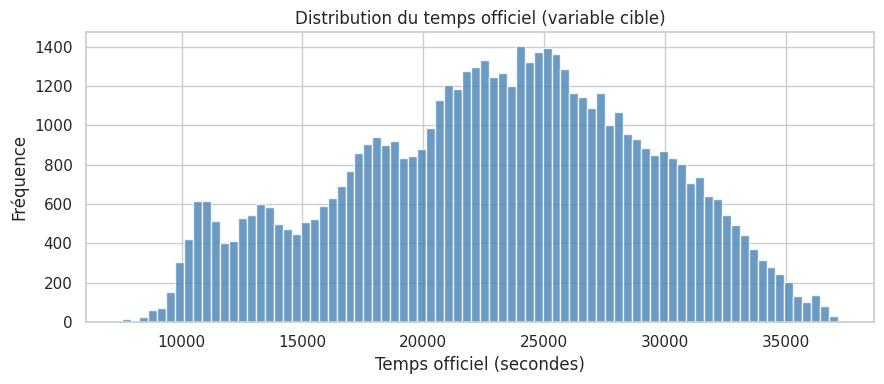

In [3]:
# Distribution de la variable cible
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['officialTime'].to_numpy(), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Temps officiel (secondes)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution du temps officiel (variable cible)')
plt.tight_layout()
plt.show()

In [4]:
X, y = split_features_target(df)
feature_names = X.columns
X_train, X_test, y_train, y_test = prepare_arrays(X, y)

print(f"Taille train : {X_train.shape[0]} | Taille test : {X_test.shape[0]}")
print(f"Nombre de features : {X_train.shape[1]}")

Taille train : 45776 | Taille test : 11444
Nombre de features : 60


## 2. Entraînement

Les deux modèles utilisent un pipeline `StandardScaler → Régression` pour que la régularisation s'applique équitablement sur toutes les features. Les hyperparamètres sont sélectionnés par validation croisée à 5 folds (critère : RMSE).

In [5]:
print("Entraînement Ridge...")
ridge_grid = train_ridge(X_train, y_train)
print(f"  Meilleur alpha : {ridge_grid.best_params_['model__alpha']}")

Entraînement Ridge...
  Meilleur alpha : 1000.0


In [6]:
print("Entraînement ElasticNet...")
enet_grid = train_elasticnet(X_train, y_train)
print(f"  Meilleur alpha    : {enet_grid.best_params_['model__alpha']}")
print(f"  Meilleur l1_ratio : {enet_grid.best_params_['model__l1_ratio']}")

Entraînement ElasticNet...
  Meilleur alpha    : 0.1
  Meilleur l1_ratio : 0.9


## 3. Évaluation sur le jeu de test

In [7]:
ridge_metrics = evaluate_model(ridge_grid, X_test, y_test)
enet_metrics  = evaluate_model(enet_grid,  X_test, y_test)

print("Ridge")
print(f"  RMSE : {ridge_metrics['rmse']:.1f} secondes")
print(f"  MAE  : {ridge_metrics['mae']:.1f} secondes")
print(f"  R²   : {ridge_metrics['r2']:.4f}")

print("\nElasticNet")
print(f"  RMSE : {enet_metrics['rmse']:.1f} secondes")
print(f"  MAE  : {enet_metrics['mae']:.1f} secondes")
print(f"  R²   : {enet_metrics['r2']:.4f}")

Ridge
  RMSE : 2451.4 secondes
  MAE  : 1861.1 secondes
  R²   : 0.8474

ElasticNet
  RMSE : 2450.1 secondes
  MAE  : 1856.9 secondes
  R²   : 0.8476


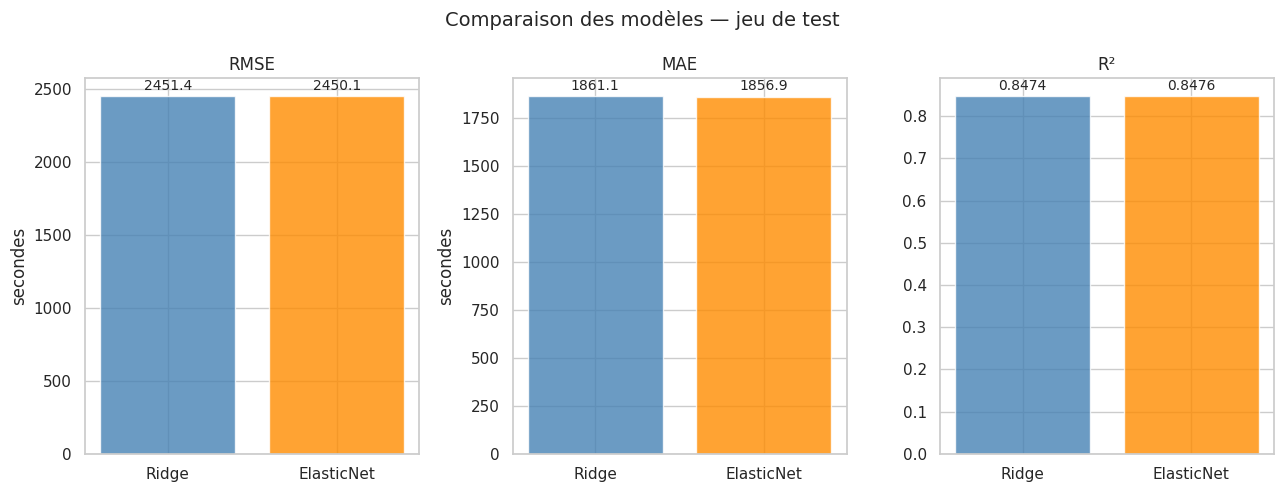

In [8]:
plot_metrics_comparison({
    'Ridge': ridge_metrics,
    'ElasticNet': enet_metrics,
})
plt.show()

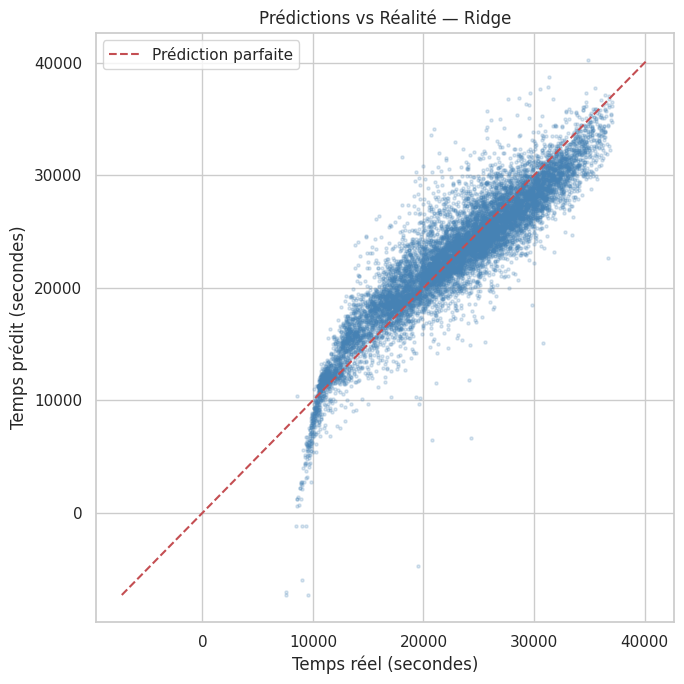

In [9]:
y_pred_ridge = ridge_grid.predict(X_test)
plot_predicted_vs_actual(y_test, y_pred_ridge, model_name='Ridge')
plt.show()

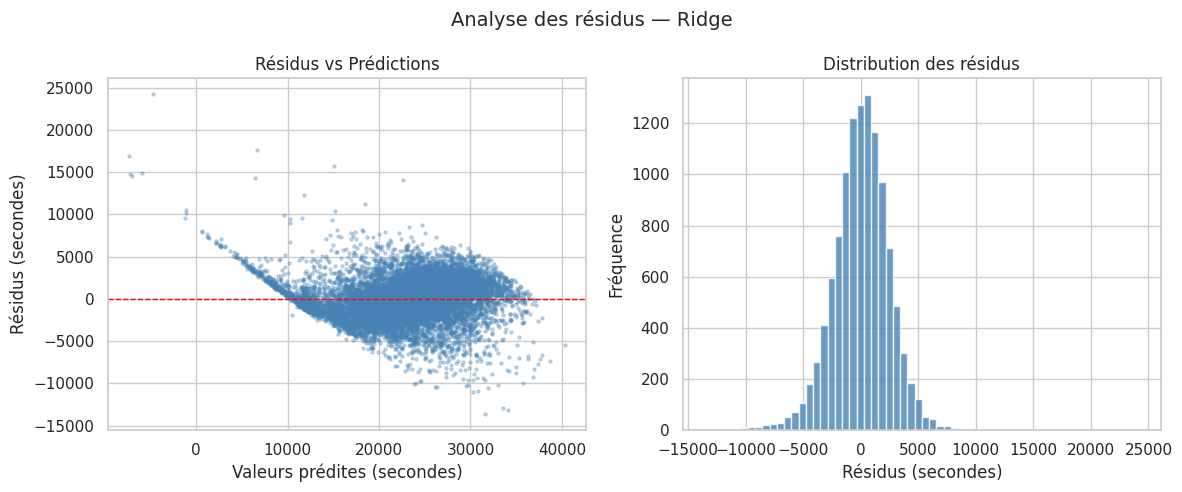

In [10]:
plot_residuals(y_test, y_pred_ridge, model_name='Ridge')
plt.show()

## 4. Intervalles de confiance des coefficients (Bootstrap)

**Pourquoi le bootstrap et pas les IC analytiques ?**  
La régularisation Ridge biaise intentionnellement les coefficients — les formules MCO classiques basées sur $(X^\top X)^{-1}$ ne s'appliquent plus. ElasticNet n'a pas d'IC analytiques standards. Le bootstrap est non-paramétrique et valide dans les deux cas : on rééchantillonne l'ensemble d'entraînement `N_BOOTSTRAP` fois, on réentraîne le pipeline complet à chaque itération, et on construit l'IC à partir des percentiles empiriques de la distribution des coefficients.

In [11]:
print(f"Bootstrap Ridge ({N_BOOTSTRAP} itérations)...")
ridge_ci = bootstrap_confidence_intervals(
    pipeline=ridge_grid.best_estimator_,
    X_train=X_train,
    y_train=y_train,
    feature_names=list(feature_names),
)
print("Terminé.")

Bootstrap Ridge (500 itérations)...
Terminé.


In [18]:
print(f"Bootstrap ElasticNet ({N_BOOTSTRAP} itérations)...")
enet_ci = bootstrap_confidence_intervals(
    pipeline=enet_grid.best_estimator_,
    X_train=X_train,
    y_train=y_train,
    feature_names=list(feature_names),
)
print("Terminé.")

Bootstrap ElasticNet (500 itérations)...
Terminé.


In [12]:
# Features significativement différentes de 0 pour Ridge
sig_ridge = significant_features(ridge_ci)
print(sig_ridge)
print(f"Features significatives (Ridge) : {len(sig_ridge)} / {len(ridge_ci)}")

{'sex_F': {'coef': 15.172996319527108, 'lower': 4.68515145711998, 'upper': 25.230523864275995}, 'sex_M': {'coef': -15.172996319505987, 'lower': -25.230523864292607, 'upper': -4.68515145712734}, 'category_EF - U23F': {'coef': 58.59565790049471, 'lower': 39.62213565791445, 'upper': 78.28832683244644}, 'category_EH - U23H': {'coef': 58.82983325261399, 'lower': 39.46642436693883, 'upper': 79.61740248590725}, 'category_M1H': {'coef': -28.051212702017683, 'lower': -48.27738405743452, 'upper': -11.181349981212955}, 'category_M2F': {'coef': -41.45990076838187, 'lower': -63.834783179788054, 'upper': -21.141300149541994}, 'category_M2H': {'coef': -50.103894166440085, 'lower': -66.90181360303157, 'upper': -32.10708974539164}, 'category_M3F': {'coef': -34.4170251578178, 'lower': -53.129129906380584, 'upper': -13.794854845793095}, 'category_M3H': {'coef': -52.7734477063184, 'lower': -72.31801752539978, 'upper': -32.093379533945246}, 'category_M4F': {'coef': -41.34775072531854, 'lower': -66.67493424

## 5. Visualisation des intervalles de confiance

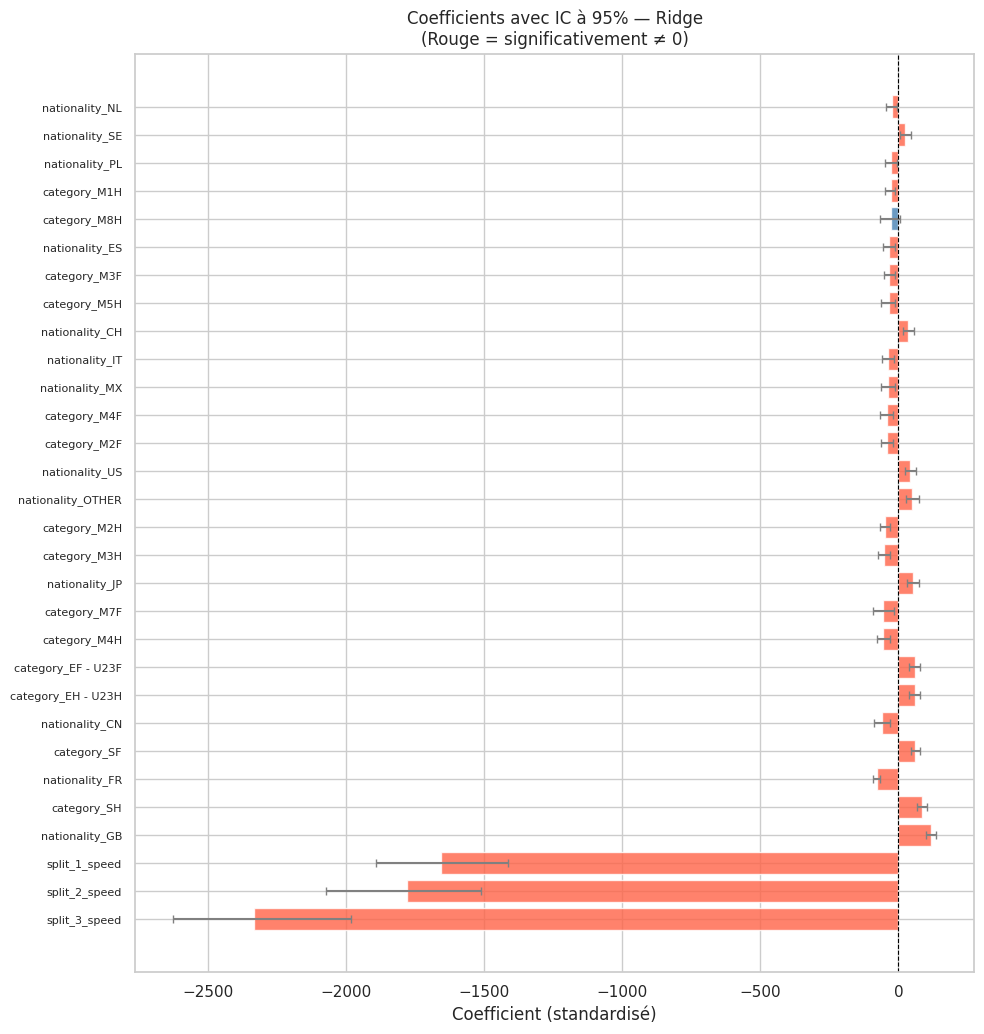

In [13]:
plot_confidence_intervals(
    ridge_ci,
    top_n=30,
    model_name='Ridge',
    confidence_level=CONFIDENCE_LEVEL,
)
plt.show()

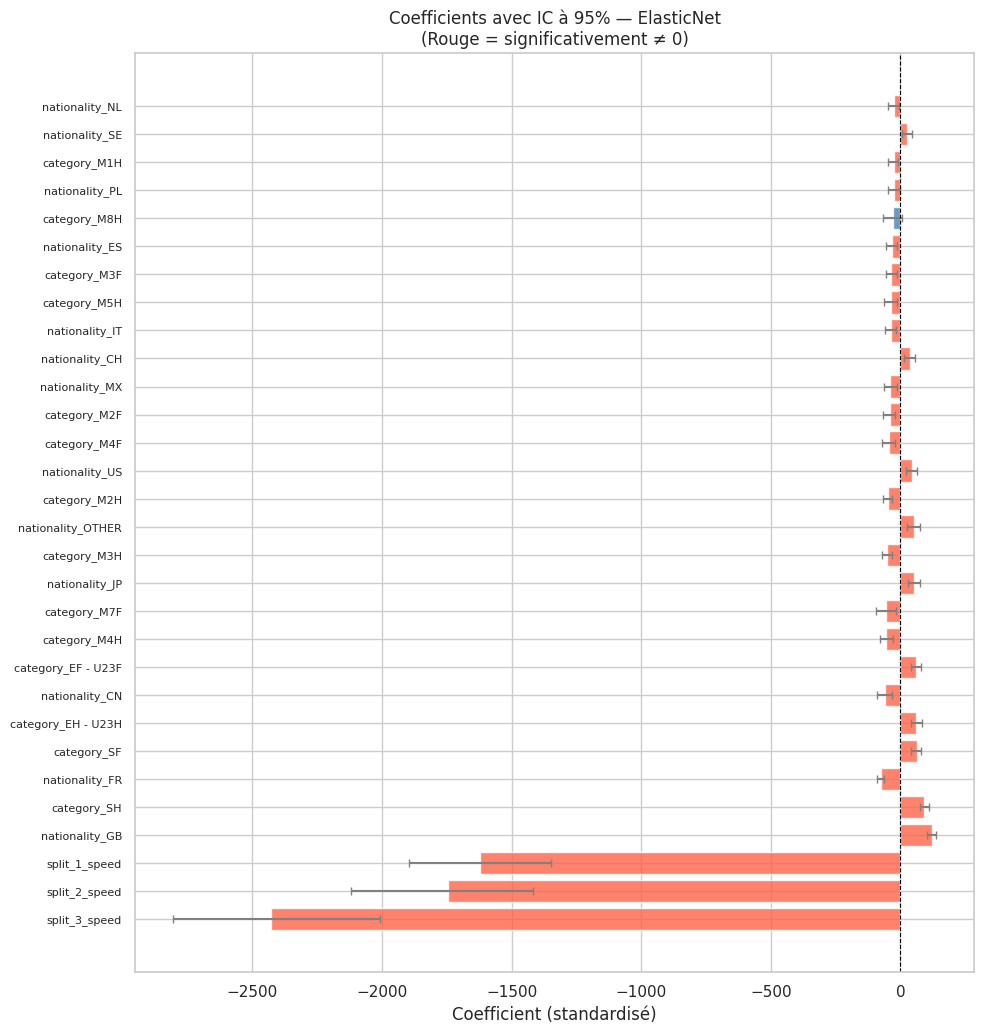

In [19]:
plot_confidence_intervals(
    enet_ci,
    top_n=30,
    model_name='ElasticNet',
    confidence_level=CONFIDENCE_LEVEL,
)
plt.show()

## 6. Changer le nombre de splits

Pour reproduire l'analyse avec un nombre différent de splits, il suffit de modifier `N_SPLITS` dans `config.py` et de relancer ce notebook. Exemple ci-dessous avec 5 splits.

In [ ]:
# Exemple : relancer le pipeline avec 5 splits
N_SPLITS_DEMO = 5

df_5 = build_dataset(n_splits=N_SPLITS_DEMO)
X_5, y_5 = split_features_target(df_5)
X_train_5, X_test_5, y_train_5, y_test_5 = prepare_arrays(X_5, y_5)

ridge_grid_5 = train_ridge(X_train_5, y_train_5)
metrics_5 = evaluate_model(ridge_grid_5, X_test_5, y_test_5)

print(f"Ridge avec {N_SPLITS_DEMO} splits")
print(f"  RMSE : {metrics_5['rmse']:.1f} s")
print(f"  R²   : {metrics_5['r2']:.4f}")

Ridge avec 12 splits
  RMSE : 2172.3 s
  R²   : 0.8799
